In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score , silhouette_samples
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
spotify_user_behavior =spark.table("spotify.spotify_user_behavior").toPandas()
CLUSTER_FEATURES_V1=[
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

iteration 4 results |k={K}
inertia: 296999.51
silhoutte: 0.16
cluster profile(means,original scale) - Iteration 4 (RobustScaler labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
49918,21.893783344027213,1.147,19.191798486199392,19.9534749445777,0.382,0.19759828550774458,0.5245642317097453
5012,153.04809395470951,3.964,22.596107648265484,41.55455158802074,0.288,0.3085307623828901,0.5916123854862374
36620,33.992538596465565,1.223,23.43114171389866,29.28208419265158,0.272,0.40427052049262063,0.5325156618768488
16450,87.4393805210667,1.175,21.71622949153109,77.65135600091361,0.284,0.2853916814103039,0.6127591479446571


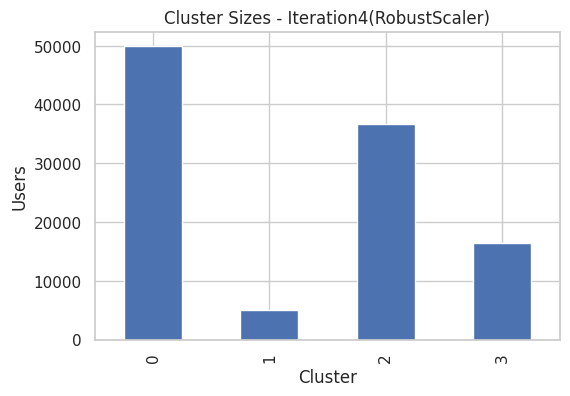

In [0]:
base = spotify_user_behavior[["user_id"]+CLUSTER_FEATURES_V1].copy()
K=4
X4=base[CLUSTER_FEATURES_V1].copy()
Robust=RobustScaler()
X4_Robust=Robust.fit_transform(X4)
X4=pd.DataFrame(X4_Robust,columns=CLUSTER_FEATURES_V1,index=base.index)
km4=KMeans(n_clusters=K,random_state=42,n_init=20,max_iter=300)
labels4=km4.fit_predict(X4)
inertia4=km4.inertia_
sil_avg4=silhouette_score(X4,labels4)
base_iter4=base.copy()
base_iter4["cluster"]=labels4
print("iteration 4 results |k={K}")
print("inertia:",round(inertia4,2))
print("silhoutte:",round(sil_avg4,3))
sizes4=base_iter4["cluster"].value_counts().sort_index()
means4=(
    base_iter4
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)
profile4=means4.copy()
profile4.insert(0,"cluster_size",sizes4)
print("cluster profile(means,original scale) - Iteration 4 (RobustScaler labels):")
display(profile4)
plt.figure(figsize=(6,4))
base_iter4["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration4(RobustScaler)")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

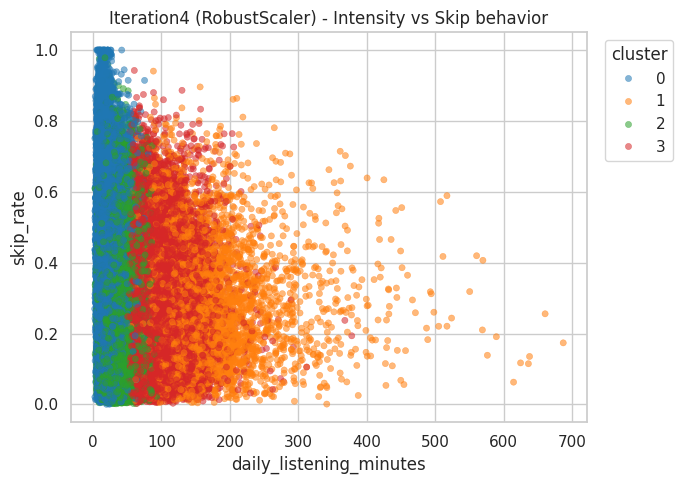

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter4,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration4 (RobustScaler) - Intensity vs Skip behavior")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()



    


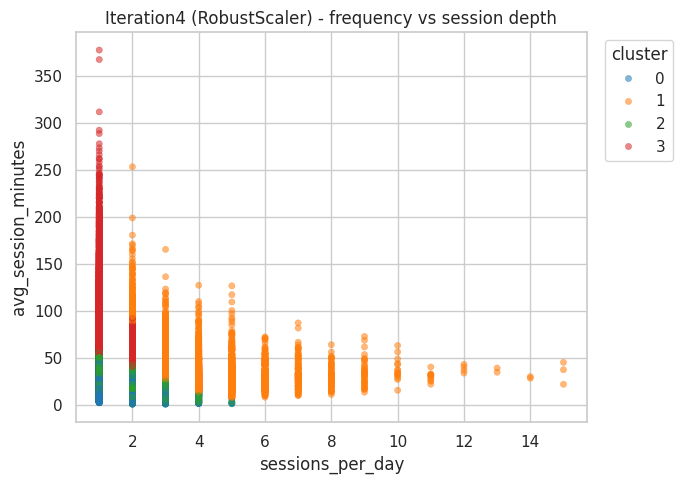

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter4,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration4 (RobustScaler) - frequency vs session depth")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

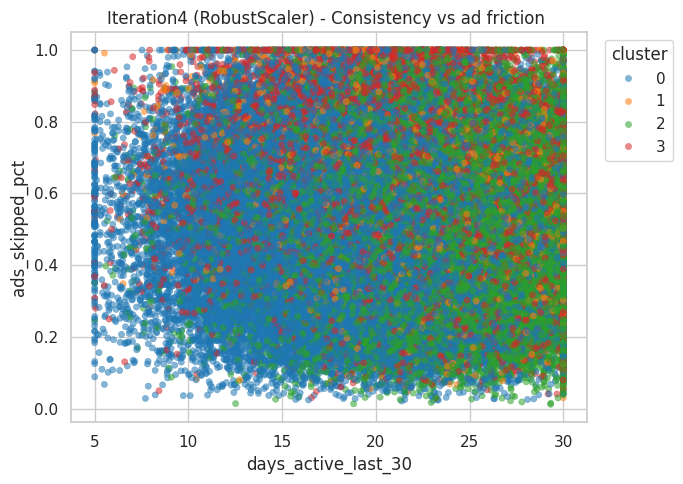

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter4,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration4 (RobustScaler) - Consistency vs ad friction ")
plt.legend(title="cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()



    


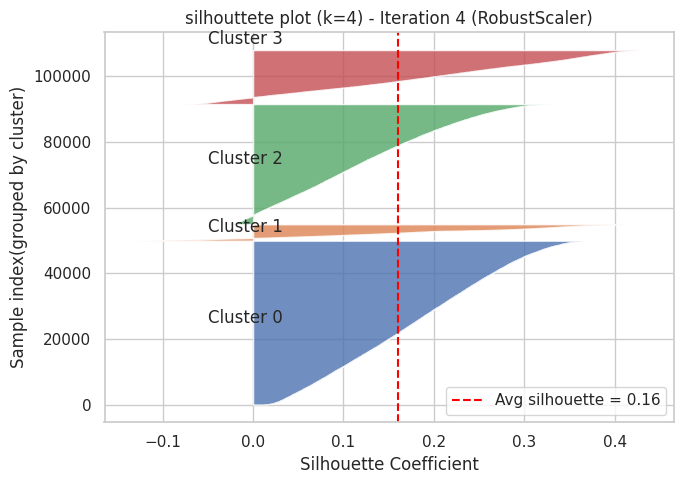

In [0]:
sil_values_4=silhouette_samples(X4,labels4)
plt.figure(figsize=(7,5))
y_lower=0
vals0=sil_values_4[labels4==0]
vals0.sort()
size0=vals0.shape[0]
y_upper=y_lower+size0
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals0,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size0,
    "Cluster 0"
)
y_lower=y_upper

vals1=sil_values_4[labels4==1]
vals1.sort()
size1=vals1.shape[0]
y_upper=y_lower+size1
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals1,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size1,
    "Cluster 1"
)
y_lower=y_upper

vals2=sil_values_4[labels4==2]
vals2.sort()    
size2=vals2.shape[0]
y_upper=y_lower+size2
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals2,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 2"
)
y_lower=y_upper    

vals3=sil_values_4[labels4==3]
vals3.sort()    
size3=vals3.shape[0]
y_upper=y_lower+size3
plt.fill_betweenx(
    np.arange(y_lower,y_upper),
    0,
    vals3,
    alpha=0.8
    )
plt.text(
    -0.05,
    y_lower+0.5*size2,
    "Cluster 3"
)
y_lower=y_upper   
plt.axvline(
    x=sil_avg4,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg4:.2f}"
)
plt.title("silhouttete plot (k=4) - Iteration 4 (RobustScaler)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
print("iteration  4avg Silhoutte:",round(sil_avg4,3))

iteration  4avg Silhoutte: 0.16
